# JIVE variance plot

JIVE splits the variation of several data blocks into structure that is **shared** between them and structure that belongs to each **alone**. This plot makes that split visible: one bar per block, stacked into three parts — residual at the base, individual above it, joint on top — so how much of a block is shared, how much is its own, and how much neither structure catches all read at a glance.

    plot_jive_variance(blocks, joint, individual; blocknames = ..., kwargs...)

It serves JIVE alone, since JIVE is the model that separates joint from individual variation:

    jive      plot_jive_variance(Dat, m.J, m.A)

The blocks are passed alongside the fit because the fractions are measured against the total variation of each block, which the fitted model does not store. The single-table models have no blocks to compare, and the two-block correlation models separate no joint from individual variation, so no other model has this figure.

The three fractions sum to one, so every bar reaches the same height and what we read is how the whole of each block divides.

## Setup

In [2]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs
using Statistics
using LinearAlgebra


## A simulated example

Three blocks of different sizes, each built from a signal shared by all three plus a signal of its own plus noise — so every bar should carry a real joint part, a real individual part, and a modest residual.

Note the layout: JIVE holds the **variables in rows and the observations in columns**, the transpose of what the single-table models expect. The three blocks therefore differ in their number of rows but share their number of columns.

In [3]:
rng = StableRNG(20240801)

n = 90    # observations, shared by every block

# the signal every block shares
joint_signal = randn(rng, 3, n)

Xs = [
    randn(rng, 10, 3) * joint_signal .+ 0.6 .* randn(rng, 10, n) .+ 0.3 .* randn(rng, 10, n),
    randn(rng, 8,  3) * joint_signal .+ 0.6 .* randn(rng, 8,  n) .+ 0.3 .* randn(rng, 8,  n),
    randn(rng, 12, 3) * joint_signal .+ 0.6 .* randn(rng, 12, n) .+ 0.3 .* randn(rng, 12, n),
]

[size(b) for b in Xs]   # variables by observations

3-element Vector{Tuple{Int64, Int64}}:
 (10, 90)
 (8, 90)
 (12, 90)

## Scaling the blocks

This step is easy to skip and gives quietly wrong answers if we do.

JIVE row-centers each block and then normalizes it, so that a block with more variables or a larger scale does not dominate the joint structure. The fitted `J` and `A` live on that **scaled** footing — so the fractions have to be measured against the scaled blocks, not the raw ones. Handing the raw blocks to the plot produces bars that look perfectly reasonable and are wrong.

So we scale first, fit on the scaled blocks, and pass those same scaled blocks to the plot.

In [4]:
nel   = [size(X, 1) * size(X, 2) for X in Xs]
sum_n = sum(nel)

# row-center each block, then normalize so no block dominates
Dat = [ let Xi = X .- mean(X, dims = 2); Xi ./ (norm(Xi) * sqrt(sum_n)); end for X in Xs ]

m = jive(Dat)

println("joint rank: ", m.r, "   individual ranks: ", m.ri)

# the fractions the plot will draw, as numbers
for i in 1:length(Dat)
    total = norm(Dat[i])^2
    vj = norm(m.J[i])^2 / total
    vi = norm(m.A[i])^2 / total
    println("  block $(i): joint ", round(vj, digits = 3),
            "  individual ", round(vi, digits = 3),
            "  residual ", round(1 - vj - vi, digits = 3))
end

Estimating ranks via permutation test...
Estimated joint rank: 1, individual ranks: [1, 1, 1]
joint rank: 1   individual ranks: [1, 1, 1]
  block 1: joint 0.527  individual 0.122  residual 0.351
  block 2: joint 0.671  individual 0.203  residual 0.127
  block 3: joint 0.482  individual 0.316  residual 0.202


## The default plot

Given the scaled blocks and the fitted structure, we get one stacked bar per block, named by index, with the legend outside the axes — the bars fill the frame to the top, so there is nowhere inside for it to sit.

The numbers printed above are what the segments should measure.

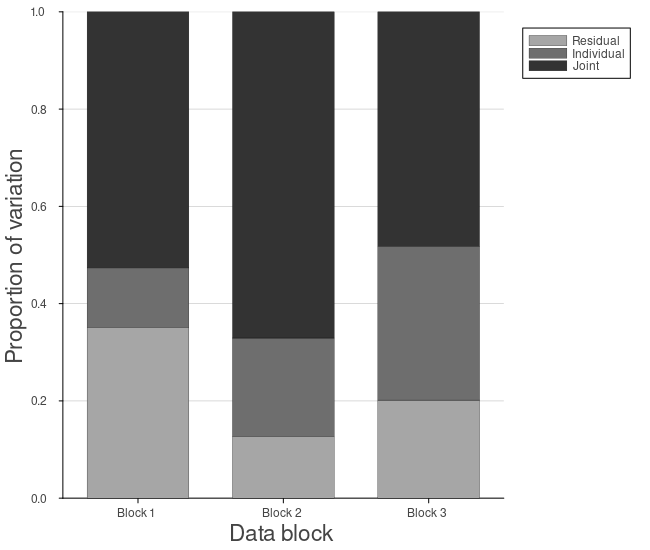

In [5]:
plot_jive_variance(Dat, m.J, m.A)

---

# Modifying the plot

There is only one argument that changes what we draw — `blocknames`, which names the bars. Everything else is styling: one color knob per segment, and the standard attributes on top.

## Naming the blocks

On real data the blocks are different assays, and naming them is most of what makes the figure readable. One name per block, in the order the blocks were fitted.

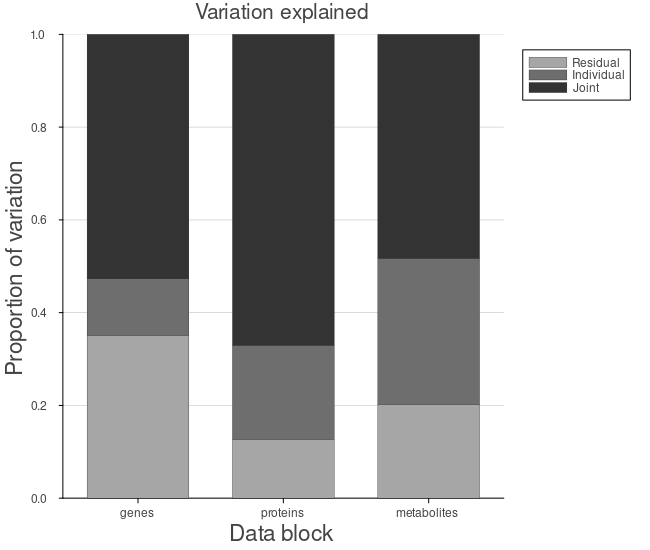

In [6]:
plot_jive_variance(Dat, m.J, m.A;
                   blocknames = ["genes", "proteins", "metabolites"],
                   title      = "Variation explained")

## The three colors

`jointcolor`, `individualcolor` and `residualcolor` set the segments. They default to three shades of grey, which prints well and keeps the emphasis on the proportions — but a single hue running dark to light does the same job in color and is easier to follow across many blocks.

Whatever we choose, the ordering matters: the joint segment should be the most prominent, since it is the one JIVE exists to find.

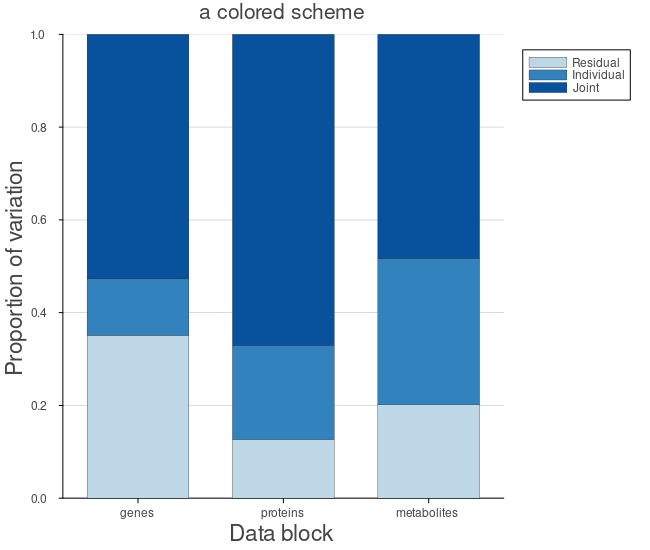

In [7]:
plot_jive_variance(Dat, m.J, m.A;
                   blocknames      = ["genes", "proteins", "metabolites"],
                   jointcolor      = "#08519c",
                   individualcolor = "#3182bd",
                   residualcolor   = "#bdd7e7",
                   title           = "a colored scheme")

## The frame

Everything the plot sets for itself yields to what we pass, including the legend placement and the canvas. Moving the legend inside works when the joint segment leaves room at the top — worth checking against the actual fit rather than assuming, since a block that is mostly joint will run the bar right up under it.

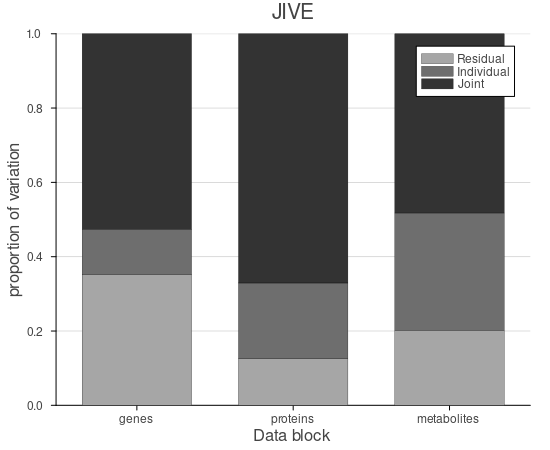

In [8]:
plot_jive_variance(Dat, m.J, m.A;
                   blocknames    = ["genes", "proteins", "metabolites"],
                   legend        = :topright,
                   ylabel        = "proportion of variation",
                   title         = "JIVE",
                   size          = (550, 450),
                   guidefontsize = 11)